In [1]:
import pandas as pd  # Work with table-like data
import numpy as np  # Handle numbers and random draws
import seaborn as sns  # Create nicer plots
import matplotlib.pyplot as plt  # Basic plotting tool
from sklearn.model_selection import train_test_split  # Split data into train and test parts
from sklearn.linear_model import LinearRegression  # Simple line-fitting model

import warnings  # Control warning messages
warnings.filterwarnings('ignore')  # Hide non-critical warnings to keep output clean

np.random.seed(42)  # Make random numbers repeat the same way each run
n = 300  # Number of pretend days of sales data

temperature = np.random.uniform(15, 35, n)  # Make temperatures between 15 and 35

weather_types = ['Sunny', 'Cloudy', 'Rainy']  # Possible weather labels
weather = np.random.choice(weather_types, size=n, p=[0.4, 0.4, 0.2])  # Pick a weather type for each day using given chances

# Base sales: 50
 # Temperature effect: +5
 # Weather Effect (Hidden coefficients):
 #   - Sunny: +40 extra sales
 #   - Cloudy: +10 extra sales
 #   - Rainy: -20 sales (decrease)
sales = 50 + (temperature * 5)  # Start with base and add temperature effect
 # Let's manually add the weather effect (using numpy masking)
sales[weather == 'Sunny'] += 40  # Add boost on sunny days
sales[weather == 'Cloudy'] += 10  # Small boost on cloudy days
sales[weather == 'Rainy'] -= 20  # Drop sales on rainy days

# Adding some noise
sales += np.random.normal(0, 10, n)  # Add random wiggles so data looks more real

# DataFrame
df = pd.DataFrame({  # Put the columns into one table
    'Temperature': temperature,  # Temperature column
    'Weather': weather,  # Weather label column
    'Sales': sales  # Sales numbers column
})

print("Raw Data:")  # Label for the preview
print(df.head())  # Show the first few rows

Raw Data:
   Temperature Weather       Sales
0    22.490802   Sunny  197.151436
1    34.014286  Cloudy  222.142702
2    29.639879  Cloudy  207.129091
3    26.973170  Cloudy  184.513425
4    18.120373  Cloudy  145.065371


In [2]:
# drop_first=True to avoid dummy variable trap
df_encoded = pd.get_dummies(df, columns=['Weather'], drop_first=True)  # Turn weather words into 0/1 columns

# Convert dummies to int type for clarity
df_encoded = df_encoded.astype(int)  # Make sure the new 0/1 columns are integer type
 # Note: Sales and Temperature columns are already numeric, so they remain unchanged; only the 0/1 columns become int.

print("Encoded (Processed) Data:")  # Label for the preview
print(df_encoded.head())  # Show the first rows of the encoded table

Encoded (Processed) Data:
   Temperature  Sales  Weather_Rainy  Weather_Sunny
0           22    197              0              1
1           34    222              0              0
2           29    207              0              0
3           26    184              0              0
4           18    145              0              0


In [3]:
X = df_encoded.drop('Sales', axis=1) # All columns except Sales become inputs
y = df_encoded['Sales']  # Sales column is what we want to predict

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  # Split into train/test sets

model = LinearRegression()  # Create a simple line-fitting model
model.fit(X_train, y_train)  # Teach the model with training data

print("Model successfully trained.")  # Confirm training finished

Model successfully trained.


In [4]:
coefficients = pd.DataFrame(model.coef_, X.columns, columns=['Effect (Coefficient)'])  # Turn learned slopes into a table
print(f"Constant (Intercept): {model.intercept_:.2f}")  # Show base sales when inputs are zero
print(coefficients)  # Show how each column changes sales

Constant (Intercept): 66.45
               Effect (Coefficient)
Temperature                4.824295
Weather_Rainy            -33.216891
Weather_Sunny             30.589960


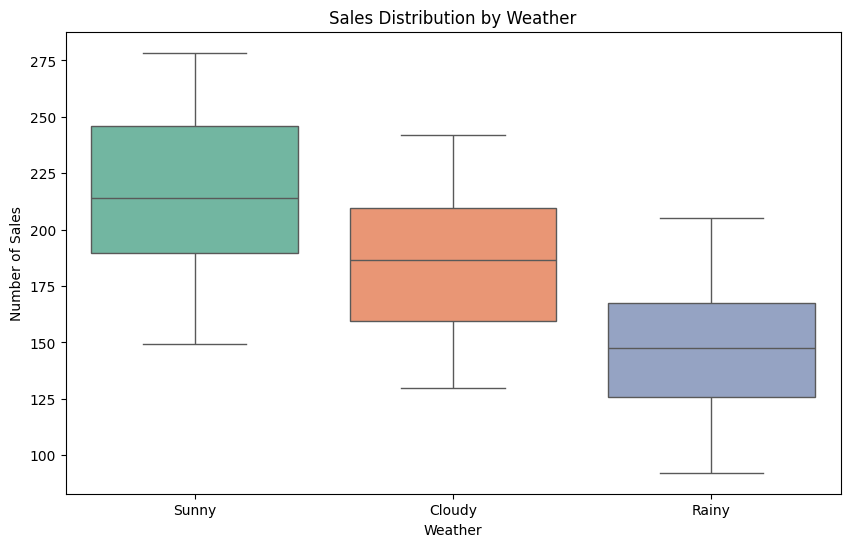

In [5]:
plt.figure(figsize=(10, 6))  # Make a wide plot
sns.boxplot(x='Weather', y='Sales', data=df, palette='Set2')  # Show sales spread for each weather type
plt.title('Sales Distribution by Weather')  # Add title
plt.ylabel('Number of Sales')  # Label y-axis
plt.show()  # Display the box plot

In [6]:
# Scenario: Temperature 25 degrees, Weather SUNNY
 # Sunny column will be 1, Rainy column will be 0.
new_data = [[25, 0, 1]]  # Temperature, Weather_Rainy, Weather_Sunny (Cloudy is the hidden base)

prediction = model.predict(new_data)  # Get model guess for the sunny day
print(f"Temperature 25°C and Weather Sunny, Prediction: {int(prediction[0])} ice creams.")  # Print rounded result

# Scenario 2: Temperature 20 degrees, Weather CLOUDY
 # Cloudy is our "hidden" reference. So we give 0 to both.
new_data_cloudy = [[20, 0, 0]]  # Temperature, Rainy=0, Sunny=0 means Cloudy
prediction_cloudy = model.predict(new_data_cloudy)  # Predict for cloudy day
print(f"Temperature 20°C and Weather Cloudy, Prediction: {int(prediction_cloudy[0])} ice creams.")  # Show the guess

Temperature 25°C and Weather Sunny, Prediction: 217 ice creams.
Temperature 20°C and Weather Cloudy, Prediction: 162 ice creams.
